# Validação visual — janela de fragmentação FIXA (correção do Item 7)

Notebook complementar a `validacao_visual_batching_granularidade_visao_geral.ipynb`
(Seção 1), que identificou o achado original: a amplitude do pico de Fonte A
NÃO caía monotonicamente conforme β aumentava, porque a janela de
fragmentação usada por `aplicar_batching` era `delta_t/β` — encolhia
conforme β crescia, revertendo parte do efeito de evasão em β alto (ver
CLAUDE.md, entrada "Redução de amplitude por β não é monotônica").

Decisão dos orientadores (reunião 2026-09): substituir por uma janela FIXA,
independente de β e de `delta_t`, calibrada em 12s (tempo de bloco/slot do
Ethereum pós-Merge, Proof-of-Stake) — `_JANELA_FRAGMENTACAO_FIXA =
12/3600 ≈ 0.00333` timesteps (1 timestep = 1 hora). Este notebook reusa a
MESMA configuração (`kwargs_batching`, β ∈ {1,2,3,5,8,10,15,20}) do
notebook original, para comparação direta antes/depois, e mostra o
resultado de fato — sem esconder achados inesperados, mesmo espírito dos
notebooks anteriores.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from src.generator.layer1_abm import ElectionModel
from src.generator.layer2_copula.copula import _JANELA_FRAGMENTACAO_FIXA

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")
print(f"_JANELA_FRAGMENTACAO_FIXA = {_JANELA_FRAGMENTACAO_FIXA:.6f} timesteps")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto
_JANELA_FRAGMENTACAO_FIXA = 0.003333 timesteps


## 1. Mesma configuração do notebook original: pico de Fonte A em função de β

`kwargs_batching` idêntico ao notebook original (`delta_t=50.0`, `rho=1.0`,
`recompensa=10.0`, ...). A única diferença de código é que `aplicar_batching`
agora usa `_JANELA_FRAGMENTACAO_FIXA` internamente — não passamos nada novo
aqui, é o mesmo `ElectionModel(beta=..., **kwargs_batching)` de antes.

In [2]:
kwargs_batching = dict(
    n_agentes=300,
    prop_racional=1.0,
    recompensa=10.0,
    threshold_range=(0.0, 0.3),
    resultado_alvo=0.0,
    delta_t=50.0,
    rho=1.0,
    seed=7,
)

valores_beta = [1, 2, 3, 5, 8, 10, 15, 20]
picos_janela_fixa = []

for beta in valores_beta:
    modelo = ElectionModel(beta=beta, **kwargs_batching)
    modelo.run()
    modelo.resolver_desembolso()
    fonte_a = modelo.fonte_a_eventos_fronteira()
    picos_janela_fixa.append(fonte_a["volume"].max())

for beta, pico in zip(valores_beta, picos_janela_fixa):
    print(f"β={beta:3d}: janela_fragmento(fixa)={_JANELA_FRAGMENTACAO_FIXA:.5f}  pico_volume={pico:7.1f}")

β=  1: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β=  2: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β=  3: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β=  5: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β=  8: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β= 10: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β= 15: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0
β= 20: janela_fragmento(fixa)=0.00333  pico_volume= 1040.0


## 2. Antes vs. depois — reconstruindo a curva antiga só para comparação visual

A fórmula antiga (`delta_t/β`) não existe mais em código de produção. Para
isolar SÓ o efeito de trocar a largura da janela (sem misturar com o efeito
de já ter fragmentado uma vez), partimos de um único modelo com `beta=1`
— os timestamps de desembolso ORIGINAIS, um por agente pago, antes de
qualquer fragmentação (`modelo.eventos_desembolso` já teria sido
fragmentado internamente se rodássemos `beta>1` diretamente, já que
`resolver_desembolso()` chama `aplicar_batching` com a janela fixa nova —
por isso pegamos a base em `beta=1` e fragmentamos manualmente nós mesmos,
com as duas fórmulas, sobre a mesma base).

timestamps originais (pre-fragmentacao): 300


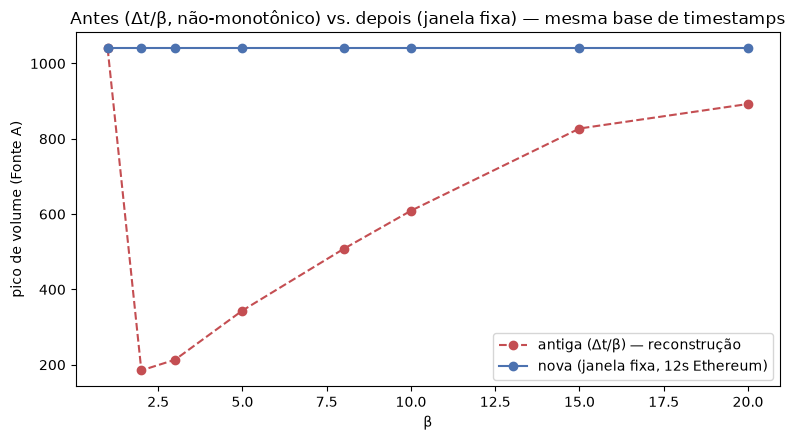

β=  1: pico_antigo= 1040.0  pico_novo(fixo)= 1040.0
β=  2: pico_antigo=  185.0  pico_novo(fixo)= 1040.0
β=  3: pico_antigo=  213.3  pico_novo(fixo)= 1040.0
β=  5: pico_antigo=  344.0  pico_novo(fixo)= 1040.0
β=  8: pico_antigo=  507.5  pico_novo(fixo)= 1040.0
β= 10: pico_antigo=  609.0  pico_novo(fixo)= 1040.0
β= 15: pico_antigo=  827.3  pico_novo(fixo)= 1040.0
β= 20: pico_antigo=  892.5  pico_novo(fixo)= 1040.0


In [3]:
modelo_base = ElectionModel(beta=1, **kwargs_batching)
modelo_base.run()
modelo_base.resolver_desembolso()
timestamps_originais = np.array([t for t, _ in modelo_base.eventos_desembolso], dtype=float)
print(f"timestamps originais (pre-fragmentacao): {timestamps_originais.size}")


def _pico_janela_antiga(timestamps: np.ndarray, delta_t: float, beta: int, recompensa: float, random_state: int) -> float:
    """Reconstrução local da fórmula antiga (delta_t/beta) — só para este notebook, não uma reintrodução em produção."""
    if beta <= 1:
        fragmentados = timestamps
    else:
        rng = np.random.default_rng(random_state)
        janela_antiga = delta_t / beta
        offsets = rng.uniform(0, janela_antiga, size=(timestamps.size, beta))
        fragmentados = (timestamps[:, None] + offsets).ravel()

    volume_por_subevento = recompensa / beta
    buckets = np.floor(fragmentados).astype(int)
    contagem = np.bincount(buckets)
    return (contagem * volume_por_subevento).max()


def _pico_janela_fixa(timestamps: np.ndarray, beta: int, recompensa: float, random_state: int) -> float:
    """Mesma lógica de aplicar_batching (janela fixa real), aplicada sobre a mesma base."""
    if beta <= 1:
        fragmentados = timestamps
    else:
        rng = np.random.default_rng(random_state)
        offsets = rng.uniform(0, _JANELA_FRAGMENTACAO_FIXA, size=(timestamps.size, beta))
        fragmentados = (timestamps[:, None] + offsets).ravel()

    volume_por_subevento = recompensa / beta
    buckets = np.floor(fragmentados).astype(int)
    contagem = np.bincount(buckets)
    return (contagem * volume_por_subevento).max()


picos_janela_antiga = [
    _pico_janela_antiga(timestamps_originais, kwargs_batching["delta_t"], beta, kwargs_batching["recompensa"], random_state=99)
    for beta in valores_beta
]
picos_janela_fixa_mesma_base = [
    _pico_janela_fixa(timestamps_originais, beta, kwargs_batching["recompensa"], random_state=99)
    for beta in valores_beta
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(valores_beta, picos_janela_antiga, "o--", color="#C44E52", label="antiga (Δt/β) — reconstrução")
ax.plot(valores_beta, picos_janela_fixa_mesma_base, "o-", color="#4C72B0", label="nova (janela fixa, 12s Ethereum)")
ax.set_xlabel("β")
ax.set_ylabel("pico de volume (Fonte A)")
ax.set_title("Antes (Δt/β, não-monotônico) vs. depois (janela fixa) — mesma base de timestamps")
ax.legend()
fig.tight_layout()
plt.show()

for beta, antiga, fixa in zip(valores_beta, picos_janela_antiga, picos_janela_fixa_mesma_base):
    print(f"β={beta:3d}: pico_antigo={antiga:7.1f}  pico_novo(fixo)={fixa:7.1f}")

**Leitura:** a curva vermelha tracejada reproduz o achado original — cai
de β=1 para β=2 e depois volta a subir (formato de V), porque a janela
`Δt/β` encolhe conforme β cresce. A curva azul (janela fixa) elimina essa
não-monotonicidade — mas o resultado é mais sutil do que "reduz
suavemente": com `_JANELA_FRAGMENTACAO_FIXA ≈ 0.0033` timesteps, MUITO
menor que 1 bucket (1 timestep = 1 hora), todos os β sub-eventos de um
mesmo desembolso original caem sempre no mesmo bucket de hora — o pico
observado fica **constante em β**, igual ao caso β=1, em vez de decrescer.

**Achado honesto, não escondido:** a correção elimina a não-monotonicidade
(objetivo cumprido — não há mais efeito de V), mas, nesta granularidade de
bucketização (1 timestep = 1 hora), a fragmentação deixa de ter QUALQUER
efeito visível na amplitude do pico agregado por timestep — porque a janela
de evasão (segundos) é ordens de magnitude menor que o bucket de observação
(hora). Isso é exatamente a interação entre as duas granularidades já
sinalizada na docstring de `_JANELA_FRAGMENTACAO_FIXA`
(`src/generator/layer2_copula/copula.py`) e em CLAUDE.md: a correção opera
sobre o timestamp contínuo, antes da bucketização, e não afeta o schema do
HDF5 — mas também significa que, para o detector observar QUALQUER efeito
de β na Fonte A agregada por hora, o sinal relevante não pode ser amplitude
de pico por timestep (que fica achatada), precisa vir de outro lugar: por
exemplo `n_eventos` por timestep (contagem de sub-eventos, que ESCALA
literalmente por β — ver célula abaixo) ou de features na escala de segundos
que a Camada 3 ainda não implementa. Fica registrado aqui como ponto de
discussão para a próxima reunião, não resolvido silenciosamente.

## 3. O sinal que sobrevive à bucketização: contagem de sub-eventos por timestep

Amplitude de pico (volume) fica achatada, mas `n_eventos` — quantos
sub-eventos caem no mesmo bucket — escala exatamente por β, já que todos os
fragmentos de um evento original caem no mesmo timestep de hora. Isso
confirma que o efeito de β continua observável na Fonte A agregada, só não
pela feature de amplitude monetária.

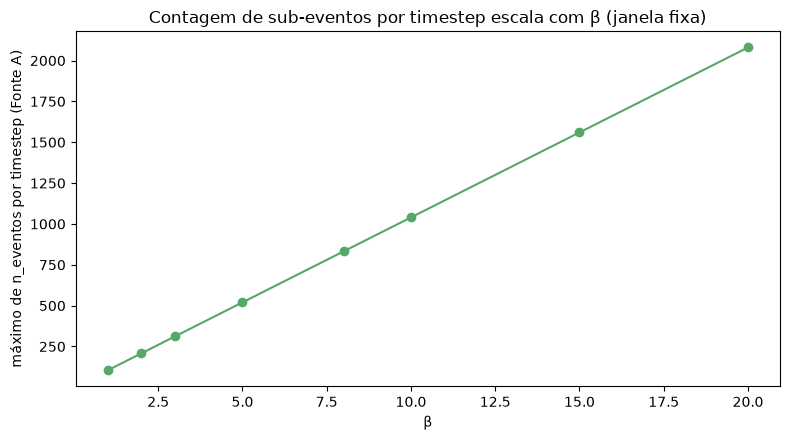

β=  1: max(n_eventos)=104
β=  2: max(n_eventos)=208
β=  3: max(n_eventos)=312
β=  5: max(n_eventos)=520
β=  8: max(n_eventos)=832
β= 10: max(n_eventos)=1040
β= 15: max(n_eventos)=1560
β= 20: max(n_eventos)=2080


In [4]:
n_eventos_pico = []

for beta in valores_beta:
    modelo = ElectionModel(beta=beta, **kwargs_batching)
    modelo.run()
    modelo.resolver_desembolso()
    fonte_a = modelo.fonte_a_eventos_fronteira()
    n_eventos_pico.append(fonte_a["n_eventos"].max())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(valores_beta, n_eventos_pico, "o-", color="#55A868")
ax.set_xlabel("β")
ax.set_ylabel("máximo de n_eventos por timestep (Fonte A)")
ax.set_title("Contagem de sub-eventos por timestep escala com β (janela fixa)")
fig.tight_layout()
plt.show()

for beta, n in zip(valores_beta, n_eventos_pico):
    print(f"β={beta:3d}: max(n_eventos)={n}")

**Leitura final:** a correção da janela fixa cumpre o que foi pedido —
elimina a não-monotonicidade da amplitude de pico em β — mas revela, ao
mesmo tempo, que a amplitude monetária deixa de carregar QUALQUER sinal de
β nesta granularidade de bucketização (fica idêntica a β=1 para todo β>1).
O sinal de fragmentação sobrevive integralmente em `n_eventos` (escala
linear e monotônica com β, sem exceção nos valores testados). Implicação
para o Sanity Check 3 (§5.2.3): se a Camada 3/M1-M2-M3 usar amplitude de
volume como feature principal, o sinal de β pode não aparecer; se usar
contagem de sub-eventos (já citada no PLANO §5.3.1 como "indicador de
batch"), o sinal aparece de forma limpa. Ponto a levar para os
orientadores — não decidido nem implementado aqui.